# Análisis de Rendimiento - Despachos en Bodega
## Proyecto de Investigación de Operaciones y Ciencia de Datos

- **Objetivo**: Analizar mi desempeño como despachador para identificar oportunidades de mejora, optimizar la productividad y simular jornadas de trabajo futuras.

- **Autor**: [Luis Miguel Marín Cadavid]
- **Fecha**: 12 Julio 2026
- **Fase 1**: Análisis Exploratorio de Datos (EDA) y limpieza de Datos


## Índice (Fase 1) <a id='indice'></a>

1. [Configuración Inicial](#configuracion)
2. [Carga y Exploración de Datos](#cargayexploracion)
3. [Limpieza y Preprocesamiento](#limpiezaypreprocesamiento)
4. [Análisis Estadístico](#analisisestadistico)
5. [Clasificación de Dificultad](#clasificaciondedificultad)
6. [Visualizaciones](#visualizaciones)
7. [Persistencia en SQL](#persistenciaensql)
8. [Conclusiones y Recomendaciones](#conclusiones)



## 1. Configuración Inicial <a id="configuracion"></a>
[Índice](#indice)

Importación de librerías y configuración del entorno.


In [1]:

# Importar librerías
import pandas as pd                          # Librería reina para el análisis de datos
import numpy as np                           # Cálculos numéricos avanzados. Manejo de vectores y matrices.
import matplotlib.pyplot as plt              # Librería para gráficos de Python
import seaborn as sns                        # Librería de gráficos más modernos y menos código
import sqlite3                               # Bases de datos SQL
from datetime import datetime, timedelta     # Para manejar fechas y horas. Calcular diferencias de díás, formatear textos
from scipy.stats import linregress           # Función específica para calcular regresiones lineales. (Hay tendencia o relación entre variables)
import warnings                              
warnings.filterwarnings('ignore')            # Ignoran avisos indeseados de Python.

# Configuración de visualización
plt.style.use('seaborn-v0_8-darkgrid')       # Fondo gris claro con cuadrícula blanca.
sns.set_palette("husl")                      # Distribución del color de forma uniforme
pd.set_option('display.max_columns', None)   # Muestre todas las columnas de las tablas de Pandas siempre
pd.set_option('display.max_rows', 100)       # Muestre todas las filas de las tablas de pandas siempre



## 2. Carga y Exploración de Datos <a id="cargayexploracion"></a>
[Índice](#indice)

Se carga el archivo de Excel y se realiza una exploración inicial para entender la estructura y calidad de los datos.


In [2]:

# Carga y exploración de datos

df = pd.read_excel('../data/raw/io_data_bimbo.xlsx')    # Función de pandas para leer archivos de Excel
print("Vista Preliminar de Datos Cargados")
print("\n")
print(f"Dimensiones: {df.shape}")                       # Devuelve una tupla: (número de filas, número de columnas)
print(f"Columnas: {df.columns.tolist()}\n")             # Extrae los nombres de las columnas y los convierte en una lista de Python.
print("Primeras 5 filas:")
display(df.head())      # Toma las primeras 5 filas de la tabla renderizada con bordes y colores alternos en las filas

print("\nTipos de datos:")
print(df.dtypes)        # Qué tipo de dato tiene asignado Python a cada columna

print("\nValores nulos:")
print(df.isnull().sum())  # Revisa celda por celda la tabla y coloca un True si la celda está vacía y un False si tiene datos


Vista Preliminar de Datos Cargados


Dimensiones: (513, 9)
Columnas: ['fecha', 'id_ruta', 'hora_inicio_jornada', 'hora_fin_jornada', 'tiempo_inicio_ruta', 'tiempo_fin_ruta', 'tiempo_total_jornada', 'cant_productos', 'valor_ruta']

Primeras 5 filas:


,fecha,id_ruta,hora_inicio_jornada,hora_fin_jornada,tiempo_inicio_ruta,tiempo_fin_ruta,tiempo_total_jornada,cant_productos,valor_ruta
0,2026-05-26,9375,15:00:00,23:00:00,18:18:22,18:21:47,0 days 05:13:41,37,201652
1,2026-05-26,9378,15:00:00,23:00:00,18:23:26,18:29:45,0 days 05:13:41,100,422150
2,2026-05-26,9381,15:00:00,23:00:00,18:30:49,18:35:58,0 days 05:13:41,48,194344
3,2026-05-26,9383,15:00:00,23:00:00,18:37:29,18:39:21,0 days 05:13:41,7,59647
4,2026-05-26,7603,15:00:00,23:00:00,17:09:55,17:28:17,0 days 05:13:41,143,957551



Tipos de datos:
fecha                    datetime64[us]
id_ruta                           int64
hora_inicio_jornada              object
hora_fin_jornada                 object
tiempo_inicio_ruta               object
tiempo_fin_ruta                  object
tiempo_total_jornada    timedelta64[us]
cant_productos                    int64
valor_ruta                        int64
dtype: object

Valores nulos:
fecha                   0
id_ruta                 0
hora_inicio_jornada     0
hora_fin_jornada        0
tiempo_inicio_ruta      0
tiempo_fin_ruta         0
tiempo_total_jornada    0
cant_productos          0
valor_ruta              0
dtype: int64


### Observaciones iniciales

- **Dimensiones:** El data set tiene `487` filas y `9` columnas
- **Columnas clave:** `fecha`, `id_ruta`, `tiempo_inicio_ruta`, `tiempo_fin_ruta`
- **Problemas identificados:**
    - Los tiempos están como strings (no como datetime)
    - Algunos tiempos cruzan la medianoche (por ejemplo: 23:41:54 - 0:05:27)


## 3. Limpieza y Preprocesamiento <a id="limpiezaypreprocesamiento"></a>
[Índice](#indice)

Transformamos los datos para hacerlos operables:
- Convertir fechas a datetime
- Procesar fórmulas de Excel en `valor_ruta`
- Convertir tiempos a formato operativo (timedelta)
- Calcular métricas clave:
  - Tiempo de preparación por ruta (minutos)
  - Velocidad de despacho (productos/hora)

In [3]:
# Clonación y conversión de fechas
def preprocesar_datos(df):
    """Función completa de preprocesamiento"""
    df = df.copy()  # Crea una copia independiente del DataFrame original.
    
    # 1. Convertir fecha
    df['fecha'] = pd.to_datetime(df['fecha'])  # Transforma la columna fecha a un formato de tiempo real, para que Python sepa qué día es
    
    # 2. Limpieza de costo de ruta
    def calcular_valor_ruta(row):
        valor = row['valor_ruta']
        cantidad = row['cant_productos']
        if pd.isna(valor) or valor == '': # Si la celda está vacía devuelve un nulo en Python
            return np.nan
        try:
            if isinstance(valor, str) and '=' in valor: # Si el valor es texto y contiene un signo '=' se asume un error de fórmula
                return float(3672 * cantidad)  # Se multiplica la cantidad de productos por la tarija fija de 3672
            return float(valor) # Guarda como valor real
        except:
            return np.nan # si falla en la conversión, pone un nulo para que no se rompa el programa
    
    df['valor_ruta'] = df.apply(calcular_valor_ruta, axis=1)
    
    # 3. Convertir tiempos
    def convertir_a_timedelta(tiempo):
        if pd.isna(tiempo):
            return pd.NaT
        if isinstance(tiempo, pd.Timedelta):
            return tiempo
        if hasattr(tiempo, 'hour'):
            return pd.Timedelta(hours=tiempo.hour, minutes=tiempo.minute, seconds=tiempo.second)
        if isinstance(tiempo, str):
            tiempo = tiempo.strip()
            if 'day' in tiempo.lower():
                try:
                    tiempo = tiempo.replace('days', 'day').replace('days,', 'day,')
                    if ',' in tiempo:
                        parts = tiempo.split(',')
                        days = int(parts[0].strip().split()[0])
                        time_part = parts[1].strip()
                    else:
                        parts = tiempo.split()
                        days = int(parts[0])
                        time_part = parts[2] if len(parts) > 2 else parts[1]
                    h, m, s = map(int, time_part.split(':'))
                    return pd.Timedelta(days=days, hours=h, minutes=m, seconds=s)
                except:
                    return pd.NaT
            try:
                parts = tiempo.split(':')
                if len(parts) == 3:
                    h, m, s = map(int, parts)
                    return pd.Timedelta(hours=h, minutes=m, seconds=s)
                elif len(parts) == 2:
                    h, m = map(int, parts)
                    return pd.Timedelta(hours=h, minutes=m)
            except:
                pass
        try:
            return pd.to_timedelta(tiempo)
        except:
            return pd.NaT
    
    df['tiempo_inicio_ruta_delta'] = df['tiempo_inicio_ruta'].apply(convertir_a_timedelta)
    df['tiempo_fin_ruta_delta'] = df['tiempo_fin_ruta'].apply(convertir_a_timedelta)
    
    # 4. Calcular tiempo de preparación
    def calcular_tiempo_preparacion(row):
        inicio = row['tiempo_inicio_ruta_delta']
        fin = row['tiempo_fin_ruta_delta']
        if pd.isna(inicio) or pd.isna(fin):
            return np.nan
        if fin < inicio:
            fin += pd.Timedelta(days=1) # Si el tiempo de fin es menor al de inicio se suma un día al fin para que el cálculo sea positivo
        return (fin - inicio).total_seconds() / 60 # Cuánto tardó en hacerse la ruta y se guarda en minutos

    df['tiempo_preparacion_minutos'] = df.apply(calcular_tiempo_preparacion, axis=1)
    
    # 5. Calcular velocidad
    df['velocidad_despacho'] = df['cant_productos'] / (df['tiempo_preparacion_minutos'] / 60)
    # Calcula el rendimiento de la operación. La métrica final es Productos despachados / hora
    
    # 6. Limpiar outliers: El registro de datos es válido solo si cumple con
    condiciones = (
        (df['tiempo_preparacion_minutos'] >= 1) & # El tiempo de preparación duró entre 1 minuto y 480 minutos
        (df['tiempo_preparacion_minutos'] <= 480) &
        (df['velocidad_despacho'] > 0) & # La velocidad de despacho es mayor a 0 y menor a 50000 productos por hora
        (df['velocidad_despacho'] < 50000) &
        (df['cant_productos'] > 0) # Se despachó al menos un producto
    )
    
    df_clean = df[condiciones].copy()
    
    # 7. Clasificar dificultad con cuartiles (SOLO si hay datos)
    if len(df_clean) > 0:
        # Calcular cuartiles de velocidad (basado en los datos reales)
        q1 = df_clean['velocidad_despacho'].quantile(0.25) # Rutas lentas
        q3 = df_clean['velocidad_despacho'].quantile(0.75) # Rutas rápidas
        
        print(f"\nUmbrales de dificultad basados en cuartiles:")
        print(f"  • Difícil (Q1):  < {q1:.1f} prod/h") # Rutas lentas umbral de 25%
        print(f"  • Media (Q1-Q3): {q1:.1f} - {q3:.1f} prod/h") # Rutas media está en medio de ambos valores
        print(f"  • Fácil (Q3):    > {q3:.1f} prod/h") # Rutas rápidas el 25% por encima del umbral
        
        def clasificar_dificultad_dinamica(velocidad):
            if velocidad < q1:
                return 'Difícil'
            elif velocidad <= q3:
                return 'Media'
            else:
                return 'Fácil'
        
        df_clean['mi_dificultad'] = df_clean['velocidad_despacho'].apply(clasificar_dificultad_dinamica)
        
        # Mostrar nueva distribución
        print("\nDistribución de dificultad:")
        print(df_clean['mi_dificultad'].value_counts())
        print(f"\nPorcentajes:")
        print(df_clean['mi_dificultad'].value_counts(normalize=True) * 100)
    
    return df_clean

# Aplicar preprocesamiento
df_clean = preprocesar_datos(df)

print("\n")
print("Resumen de la limpieza")

print(f"Registros originales: {len(df):,}")
print(f"Registros después de limpieza: {len(df_clean):,}")
print(f"Registros eliminados: {len(df) - len(df_clean):,}")
if len(df) > 0:
    print(f"Porcentaje retenido: {len(df_clean)/len(df)*100:.1f}%")

if len(df_clean) > 0:
    print("\nDatos procesados correctamente")
    print(f"\nResumen de velocidad:")
    print(df_clean['velocidad_despacho'].describe())
    print("\nDistribución de dificultad:")
    print(df_clean['mi_dificultad'].value_counts())
    print("\nPrimeras filas:")
    display(df_clean.head())
else:
    print("\nNo hay datos después de la limpieza.")


Umbrales de dificultad basados en cuartiles:
  • Difícil (Q1):  < 839.1 prod/h
  • Media (Q1-Q3): 839.1 - 2276.9 prod/h
  • Fácil (Q3):    > 2276.9 prod/h

Distribución de dificultad:
mi_dificultad
Media      254
Difícil    128
Fácil      128
Name: count, dtype: int64

Porcentajes:
mi_dificultad
Media      49.803922
Difícil    25.098039
Fácil      25.098039
Name: proportion, dtype: float64


Resumen de la limpieza
Registros originales: 513
Registros después de limpieza: 510
Registros eliminados: 3
Porcentaje retenido: 99.4%

Datos procesados correctamente

Resumen de velocidad:
count      510.000000
mean      1787.114480
std       1735.299146
min         20.689655
25%        839.085008
50%       1454.257035
75%       2276.907371
max      21446.808511
Name: velocidad_despacho, dtype: float64

Distribución de dificultad:
mi_dificultad
Media      254
Difícil    128
Fácil      128
Name: count, dtype: int64

Primeras filas:


,fecha,id_ruta,hora_inicio_jornada,hora_fin_jornada,tiempo_inicio_ruta,tiempo_fin_ruta,tiempo_total_jornada,cant_productos,valor_ruta,tiempo_inicio_ruta_delta,tiempo_fin_ruta_delta,tiempo_preparacion_minutos,velocidad_despacho,mi_dificultad
0,2026-05-26,9375,15:00:00,23:00:00,18:18:22,18:21:47,0 days 05:13:41,37,201652.0,0 days 18:18:22,0 days 18:21:47,3.416667,649.756098,Difícil
1,2026-05-26,9378,15:00:00,23:00:00,18:23:26,18:29:45,0 days 05:13:41,100,422150.0,0 days 18:23:26,0 days 18:29:45,6.316667,949.868074,Media
2,2026-05-26,9381,15:00:00,23:00:00,18:30:49,18:35:58,0 days 05:13:41,48,194344.0,0 days 18:30:49,0 days 18:35:58,5.150000,559.223301,Difícil
3,2026-05-26,9383,15:00:00,23:00:00,18:37:29,18:39:21,0 days 05:13:41,7,59647.0,0 days 18:37:29,0 days 18:39:21,1.866667,225.000000,Difícil
4,2026-05-26,7603,15:00:00,23:00:00,17:09:55,17:28:17,0 days 05:13:41,143,957551.0,0 days 17:09:55,0 days 17:28:17,18.366667,467.150635,Difícil


In [4]:
# Identificar los registros eliminados

print("Registros eliminados en la limpieza:")

# Crear una copia y aplicar las mismas transformaciones que en el preprocesamiento
df_temp = df.copy()
df_temp['fecha'] = pd.to_datetime(df_temp['fecha'])

# Reutilizar la función de conversión 
try: # Mecanismo de defensa por si no se ejecuta la celda anterior
    convertir_a_timedelta
except NameError:
    def convertir_a_timedelta(tiempo):
        if pd.isna(tiempo):
            return pd.NaT
        if isinstance(tiempo, pd.Timedelta):
            return tiempo
        if hasattr(tiempo, 'hour'):
            return pd.Timedelta(hours=tiempo.hour, minutes=tiempo.minute, seconds=tiempo.second)
        if isinstance(tiempo, str):
            tiempo = tiempo.strip()
            if 'day' in tiempo.lower():
                try:
                    tiempo = tiempo.replace('days', 'day').replace('days,', 'day,')
                    if ',' in tiempo:
                        parts = tiempo.split(',')
                        days = int(parts[0].strip().split()[0])
                        time_part = parts[1].strip()
                    else:
                        parts = tiempo.split()
                        days = int(parts[0])
                        time_part = parts[2] if len(parts) > 2 else parts[1]
                    h, m, s = map(int, time_part.split(':'))
                    return pd.Timedelta(days=days, hours=h, minutes=m, seconds=s)
                except:
                    return pd.NaT
            try:
                parts = tiempo.split(':')
                if len(parts) == 3:
                    h, m, s = map(int, parts)
                    return pd.Timedelta(hours=h, minutes=m, seconds=s)
                elif len(parts) == 2:
                    h, m = map(int, parts)
                    return pd.Timedelta(hours=h, minutes=m)
            except:
                pass
        try:
            return pd.to_timedelta(tiempo)
        except:
            return pd.NaT

# Convertir tiempos
df_temp['inicio_delta'] = df_temp['tiempo_inicio_ruta'].apply(convertir_a_timedelta)
df_temp['fin_delta'] = df_temp['tiempo_fin_ruta'].apply(convertir_a_timedelta)

# Calcular tiempo de preparación
def calc_diff(row):
    inicio = row['inicio_delta']
    fin = row['fin_delta']
    if pd.isna(inicio) or pd.isna(fin):
        return np.nan
    if fin < inicio:
        fin += pd.Timedelta(days=1)
    return (fin - inicio).total_seconds() / 60

df_temp['tiempo_preparacion_minutos'] = df_temp.apply(calc_diff, axis=1)

# Calcular velocidad
df_temp['velocidad_despacho'] = df_temp['cant_productos'] / (df_temp['tiempo_preparacion_minutos'] / 60)

# Diagnosticar tiempos calculados
print(f"\nDiagnóstico de conversión:")
print(f"  Registros con inicio convertido: {df_temp['inicio_delta'].notna().sum()}/{len(df_temp)}") # Cuántas celdas tienen datos válidos
print(f"  Registros con fin convertido: {df_temp['fin_delta'].notna().sum()}/{len(df_temp)}")
print(f"  Registros con tiempo calculado: {df_temp['tiempo_preparacion_minutos'].notna().sum()}/{len(df_temp)}")

# Identificar los registros que NO pasaron el filtro
condiciones = (
    (df_temp['tiempo_preparacion_minutos'] >= 1) &
    (df_temp['tiempo_preparacion_minutos'] <= 480) &
    (df_temp['velocidad_despacho'] > 0) &
    (df_temp['velocidad_despacho'] < 50000) &
    (df_temp['cant_productos'] > 0)
)

# Aplicar condiciones con manejo de NaN
mask = condiciones.fillna(False) # Cualquier nulo se convierte en False
registros_eliminados = df_temp[~mask] # Trae todo lo que no sea correcto. Así se aislan los registros eliminados

print(f"\nRegistros eliminados: {len(registros_eliminados)}")

if len(registros_eliminados) > 0:
    print("\nDetalle de registros eliminados:")
    display(registros_eliminados[[
        'fecha', 'id_ruta', 'cant_productos', 
        'tiempo_inicio_ruta', 'tiempo_fin_ruta',
        'tiempo_preparacion_minutos', 'velocidad_despacho'
    ]].head(10))
    
    print("\nRazones de eliminación:")
    # Contar cada condición por separado
    tiempo_menor_1 = (registros_eliminados['tiempo_preparacion_minutos'] < 1).sum() if 'tiempo_preparacion_minutos' in registros_eliminados else 0
    tiempo_mayor_480 = (registros_eliminados['tiempo_preparacion_minutos'] > 480).sum() if 'tiempo_preparacion_minutos' in registros_eliminados else 0
    velocidad_cero = (registros_eliminados['velocidad_despacho'] <= 0).sum() if 'velocidad_despacho' in registros_eliminados else 0
    velocidad_extrema = (registros_eliminados['velocidad_despacho'] >= 50000).sum() if 'velocidad_despacho' in registros_eliminados else 0
    productos_cero = (registros_eliminados['cant_productos'] <= 0).sum() if 'cant_productos' in registros_eliminados else 0
    tiempo_nan = registros_eliminados['tiempo_preparacion_minutos'].isna().sum() if 'tiempo_preparacion_minutos' in registros_eliminados else 0
    
    print(f"  - Tiempo < 1 min: {tiempo_menor_1}") # Rutas que terminan casi al momento de iniciar
    print(f"  - Tiempo > 480 min: {tiempo_mayor_480}") # Rutas de más de 8 horas
    print(f"  - Tiempo NaN (no convertido): {tiempo_nan}") # Registros donde la hora de inicio o fin venía dañada o vacía
    print(f"  - Velocidad = 0 o negativa: {velocidad_cero}") #Registros vacíos donde no se entregó nada
    print(f"  - Velocidad > 50000: {velocidad_extrema}") # Registros con velocidades muy elevadas
    print(f"  - Cantidad de productos <= 0: {productos_cero}")
    
    # Mostrar estadísticas de los eliminados
    if len(registros_eliminados) > 0:
        print("\nEstadísticas de registros eliminados:")
        if 'tiempo_preparacion_minutos' in registros_eliminados:
            print(registros_eliminados['tiempo_preparacion_minutos'].describe())
else:
    print("\nNo se eliminaron registros")

# Limpiar columnas temporales
df_temp = df_temp.drop(columns=['inicio_delta', 'fin_delta'], errors='ignore')

Registros eliminados en la limpieza:

Diagnóstico de conversión:
  Registros con inicio convertido: 513/513
  Registros con fin convertido: 513/513
  Registros con tiempo calculado: 513/513

Registros eliminados: 3

Detalle de registros eliminados:


,fecha,id_ruta,cant_productos,tiempo_inicio_ruta,tiempo_fin_ruta,tiempo_preparacion_minutos,velocidad_despacho
60,2026-05-29,9339,18,18:19:54,18:20:44,0.833333,1296.000000
61,2026-05-29,9344,18,18:22:06,18:23:04,0.966667,1117.241379
505,2026-07-14,9413,1,21:24:20,21:25:19,0.983333,61.016949



Razones de eliminación:
  - Tiempo < 1 min: 3
  - Tiempo > 480 min: 0
  - Tiempo NaN (no convertido): 0
  - Velocidad = 0 o negativa: 0
  - Velocidad > 50000: 0
  - Cantidad de productos <= 0: 0

Estadísticas de registros eliminados:
count    3.000000
mean     0.927778
std      0.082215
min      0.833333
25%      0.900000
50%      0.966667
75%      0.975000
max      0.983333
Name: tiempo_preparacion_minutos, dtype: float64


In [5]:
# Verificación de integridad de datos

print("Verificación de Integridad")

print(f"\nDimensiones: {df_clean.shape}") # Extrae el número de filas que quedaron en la tabla limpia
print(f"   Registros: {df_clean.shape[0]:,}") # Añade comas automáticamente si el número es grande
print(f"   Columnas: {df_clean.shape[1]}") # Conteo de las columnas

print(f"\nTipos de datos:")
print(df_clean.dtypes)

print(f"\nValores nulos:")
print(df_clean.isnull().sum())

print(f"\nEstadísticas descriptivas:")
display(df_clean[['cant_productos', 'tiempo_preparacion_minutos', 'velocidad_despacho']].describe()) # muestra la tabla con

print(f"\nRango de fechas:")
print(f"  Desde: {df_clean['fecha'].min()}") # qué día empezó a registrarse la información
print(f"  Hasta: {df_clean['fecha'].max()}") # Qué día se tomó el último dato
print(f"  Días únicos: {df_clean['fecha'].nunique()}") # Cuenta valores únicos, elimina duplicados para el conteo
print(f"  Rutas únicas: {df_clean['id_ruta'].nunique()}")

print("\nPrimeras filas:")
display(df_clean.head())

Verificación de Integridad

Dimensiones: (510, 14)
   Registros: 510
   Columnas: 14

Tipos de datos:
fecha                          datetime64[us]
id_ruta                                 int64
hora_inicio_jornada                    object
hora_fin_jornada                       object
tiempo_inicio_ruta                     object
tiempo_fin_ruta                        object
tiempo_total_jornada          timedelta64[us]
cant_productos                          int64
valor_ruta                            float64
tiempo_inicio_ruta_delta      timedelta64[us]
tiempo_fin_ruta_delta         timedelta64[us]
tiempo_preparacion_minutos            float64
velocidad_despacho                    float64
mi_dificultad                             str
dtype: object

Valores nulos:
fecha                         0
id_ruta                       0
hora_inicio_jornada           0
hora_fin_jornada              0
tiempo_inicio_ruta            0
tiempo_fin_ruta               0
tiempo_total_jornada          0


,cant_productos,tiempo_preparacion_minutos,velocidad_despacho
count,510.000000,510.000000,510.000000
mean,557.576471,16.652810,1787.114480
std,693.707922,11.075243,1735.299146
min,1.000000,1.033333,20.689655
25%,120.000000,8.258333,839.085008
50%,363.000000,15.508333,1454.257035
75%,836.750000,22.858333,2276.907371
max,7777.000000,88.250000,21446.808511



Rango de fechas:
  Desde: 2026-05-26 00:00:00
  Hasta: 2026-07-14 00:00:00
  Días únicos: 24
  Rutas únicas: 171

Primeras filas:


,fecha,id_ruta,hora_inicio_jornada,hora_fin_jornada,tiempo_inicio_ruta,tiempo_fin_ruta,tiempo_total_jornada,cant_productos,valor_ruta,tiempo_inicio_ruta_delta,tiempo_fin_ruta_delta,tiempo_preparacion_minutos,velocidad_despacho,mi_dificultad
0,2026-05-26,9375,15:00:00,23:00:00,18:18:22,18:21:47,0 days 05:13:41,37,201652.0,0 days 18:18:22,0 days 18:21:47,3.416667,649.756098,Difícil
1,2026-05-26,9378,15:00:00,23:00:00,18:23:26,18:29:45,0 days 05:13:41,100,422150.0,0 days 18:23:26,0 days 18:29:45,6.316667,949.868074,Media
2,2026-05-26,9381,15:00:00,23:00:00,18:30:49,18:35:58,0 days 05:13:41,48,194344.0,0 days 18:30:49,0 days 18:35:58,5.150000,559.223301,Difícil
3,2026-05-26,9383,15:00:00,23:00:00,18:37:29,18:39:21,0 days 05:13:41,7,59647.0,0 days 18:37:29,0 days 18:39:21,1.866667,225.000000,Difícil
4,2026-05-26,7603,15:00:00,23:00:00,17:09:55,17:28:17,0 days 05:13:41,143,957551.0,0 days 17:09:55,0 days 17:28:17,18.366667,467.150635,Difícil


In [6]:

# Análisis de Outliers - Velocidades Extremas
print("ANÁLISIS DE OUTLIERS - VELOCIDADES EXTREMAS")


# Identificar velocidades extremadamente altas (> 10,000 prod/h)
outliers_velocidad = df_clean[df_clean['velocidad_despacho'] > 10000] # Filas que superan los 10000 productos por hora

print(f"\nRutas con velocidad extrema (>10,000 prod/h): {len(outliers_velocidad)}") # Cuántas lineas cumplen la condición
# Verifica si hay outliers
if len(outliers_velocidad) > 0:
    print("\nDetalle de rutas con velocidad extrema:")
    display(outliers_velocidad[[ # Columnas mostradas
        'fecha', 'id_ruta', 'cant_productos', 
        'tiempo_preparacion_minutos', 'velocidad_despacho',
        'mi_dificultad'
    ]]) # Muestra tabla con columnas seleccionadas para cada ruta extrema
    
    print("\nEstadísticas de estas rutas:") # Calcula estadísticas descriptivas para las columnas seleccionadas
    display(outliers_velocidad[['cant_productos', 'tiempo_preparacion_minutos', 'velocidad_despacho']].describe()) 
    
    print("\nAnálisis:") # Resumen estadístico de las rutas extremas
    # Se calcula y muestra la media de velocidad, productos y tiempo de las rutas extremas
    print(f"  - Velocidad promedio extrema: {outliers_velocidad['velocidad_despacho'].mean():.1f} prod/h")
    print(f"  - Productos promedio: {outliers_velocidad['cant_productos'].mean():.1f}")
    print(f"  - Tiempo promedio: {outliers_velocidad['tiempo_preparacion_minutos'].mean():.1f} min")
    
    # Verificar si son rutas consistentes o casos aislados
    rutas_extremas = outliers_velocidad['id_ruta'].unique() # Obtiene los IDs de ruta únicos (sin duplicados)
    print(f"  - IDs de rutas con velocidad extrema: {', '.join([str(int(r)) for r in rutas_extremas])}") # Convierte IDs a string y los
    # une con comas
    
    if len(rutas_extremas) <= 3: # Casos aislados (posibles errores)
        print("Pocas rutas con velocidad extrema - posibles casos especiales o errores de registro")
    else: # rutas únicas, podría ser un patrón de eficiencia real
        print("Varias rutas con velocidad extrema - podría ser un patrón de eficiencia")
else:
    print("\nNo se encontraron rutas con velocidad extrema (>10,000 prod/h)")

# Identificar velocidades inusualmente bajas (< 50 prod/h)
outliers_lentos = df_clean[df_clean['velocidad_despacho'] < 50]

print(f"\nRutas con velocidad baja (<50 prod/h): {len(outliers_lentos)}")

if len(outliers_lentos) > 0:
    print("\nDetalle de rutas lentas:")
    display(outliers_lentos[[
        'fecha', 'id_ruta', 'cant_productos', 
        'tiempo_preparacion_minutos', 'velocidad_despacho',
        'mi_dificultad'
    ]])
    
    print("\nAnálisis de rutas lentas:")
    print(f"  - Velocidad promedio baja: {outliers_lentos['velocidad_despacho'].mean():.1f} prod/h")
    print(f"  - Productos promedio: {outliers_lentos['cant_productos'].mean():.1f}")
    print(f"  - Tiempo promedio: {outliers_lentos['tiempo_preparacion_minutos'].mean():.1f} min")
else:
    print("\nNo se encontraron rutas con velocidad baja (<50 prod/h)")

ANÁLISIS DE OUTLIERS - VELOCIDADES EXTREMAS

Rutas con velocidad extrema (>10,000 prod/h): 3

Detalle de rutas con velocidad extrema:


,fecha,id_ruta,cant_productos,tiempo_preparacion_minutos,velocidad_despacho,mi_dificultad
84,2026-05-30,8254,480,1.70,16941.176471,Fácil
262,2026-07-01,309,676,2.30,17634.782609,Fácil
411,2026-07-09,8254,840,2.35,21446.808511,Fácil



Estadísticas de estas rutas:


,cant_productos,tiempo_preparacion_minutos,velocidad_despacho
count,3.000000,3.000000,3.000000
mean,665.333333,2.116667,18674.255863
std,180.236881,0.361709,2426.017004
min,480.000000,1.700000,16941.176471
25%,578.000000,2.000000,17287.979540
50%,676.000000,2.300000,17634.782609
75%,758.000000,2.325000,19540.795560
max,840.000000,2.350000,21446.808511



Análisis:
  - Velocidad promedio extrema: 18674.3 prod/h
  - Productos promedio: 665.3
  - Tiempo promedio: 2.1 min
  - IDs de rutas con velocidad extrema: 8254, 309
Pocas rutas con velocidad extrema - posibles casos especiales o errores de registro

Rutas con velocidad baja (<50 prod/h): 2

Detalle de rutas lentas:


,fecha,id_ruta,cant_productos,tiempo_preparacion_minutos,velocidad_despacho,mi_dificultad
86,2026-05-30,9369,2,2.55,47.058824,Difícil
364,2026-07-07,9413,1,2.90,20.689655,Difícil



Análisis de rutas lentas:
  - Velocidad promedio baja: 33.9 prod/h
  - Productos promedio: 1.5
  - Tiempo promedio: 2.7 min


## 4. Análisis Estadístico de Rendimiento <a id="analisisestadistico"></a>
[Índice](#indice)

Se calculan métricas clave para evaluar mi desempeño en las jornadas:
- Productividad diaria (productos totales y velocidad)
- Mejor y peor día en volumen y velocidad
- Curva de aprendizaje semanal (tendencia de mejora)


In [7]:
# Verificar que hay datos para analizar

print("ANÁLISIS ESTADÍSTICO DE RENDIMIENTO")

if len(df_clean) == 0:
    print("Error: No hay datos después de la limpieza.")
    print("Revisa los criterios de filtrado.")
else:
    print(f"Datos disponibles para análisis: {len(df_clean):,} registros")

# Agrupar por día
rendimiento_diario = df_clean.groupby('fecha').agg({ # Agrupa todos los registros del mismo día. Agregan funciones de agregación
    'cant_productos': ['sum', 'mean', 'std', 'count'],
    'tiempo_preparacion_minutos': ['sum', 'mean', 'std'],
    'velocidad_despacho': ['mean', 'std']
}).round(2) # Redondea todos los valores a 2 decimales

# Renombrar columnas
rendimiento_diario.columns = [ # Se renombran las columnas en el .agg()
    'total_productos', 'promedio_ruta', 'std_ruta', 'num_rutas',
    'tiempo_total_min', 'tiempo_promedio', 'std_tiempo',
    'velocidad_promedio', 'std_velocidad'
]

print("\n")
print("RESULTADOS DEL ANÁLISIS")

# Verificar que tenemos datos diarios
if len(rendimiento_diario) == 0:
    print("No hay datos diarios para analizar")
else:
    print(f"\nDías analizados: {len(rendimiento_diario)}")
    print("\nResumen de rendimiento diario:")
    display(rendimiento_diario.head(10)) # Muestra las primeras 10 filas del resumen diario
    
    print("\nEstadísticas generales diarias:")
    display(rendimiento_diario.describe()) # Calcula estadística de las columnas (media, desviación, min, max, percentiles)
    
    # Mejores y peores días
    print("\n")
    print("MEJOR Y PEOR DÍA")
    
    try:
        idx_max_vol = rendimiento_diario['total_productos'].idxmax() # Encuentra el índice (fecha) del valor máximo en total_productos
        mejor_dia_volumen = rendimiento_diario.loc[idx_max_vol] # Obtiene la fila de ese día
        print(f"\nMejor día en volumen:")
        print(f"  Fecha: {idx_max_vol.strftime('%Y-%m-%d')}") # Convierte la fecha a formato YYYY-MM-DD
        print(f"  Productos: {mejor_dia_volumen['total_productos']:,.0f}") # Formato con miles y 0 decimales
        print(f"  Rutas: {mejor_dia_volumen['num_rutas']:.0f}")
        print(f"  Velocidad promedio: {mejor_dia_volumen['velocidad_promedio']:.1f} prod/h")
    except Exception as e:
        print(f"Error al calcular mejor día en volumen: {e}")
    
    try:
        idx_min_vol = rendimiento_diario['total_productos'].idxmin()
        peor_dia_volumen = rendimiento_diario.loc[idx_min_vol]
        print(f"\nPeor día en volumen:")
        print(f"  Fecha: {idx_min_vol.strftime('%Y-%m-%d')}")
        print(f"  Productos: {peor_dia_volumen['total_productos']:,.0f}")
        print(f"  Rutas: {peor_dia_volumen['num_rutas']:.0f}")
        print(f"  Velocidad promedio: {peor_dia_volumen['velocidad_promedio']:.1f} prod/h")
    except Exception as e:
        print(f"Error al calcular peor día en volumen: {e}")
    
    try:
        idx_max_vel = rendimiento_diario['velocidad_promedio'].idxmax()
        mejor_dia_velocidad = rendimiento_diario.loc[idx_max_vel]
        print(f"\nDía más rápido:")
        print(f"  Fecha: {idx_max_vel.strftime('%Y-%m-%d')}")
        print(f"  Velocidad promedio: {mejor_dia_velocidad['velocidad_promedio']:.1f} prod/h")
        print(f"  Productos: {mejor_dia_velocidad['total_productos']:,.0f}")
    except Exception as e:
        print(f"Error al calcular día más rápido: {e}")
    
    try:
        idx_min_vel = rendimiento_diario['velocidad_promedio'].idxmin()
        peor_dia_velocidad = rendimiento_diario.loc[idx_min_vel]
        print(f"\nDía más lento:")
        print(f"  Fecha: {idx_min_vel.strftime('%Y-%m-%d')}")
        print(f"  Velocidad promedio: {peor_dia_velocidad['velocidad_promedio']:.1f} prod/h")
        print(f"  Productos: {peor_dia_velocidad['total_productos']:,.0f}")
    except Exception as e:
        print(f"Error al calcular día más lento: {e}")

# Curva de aprendizaje
print("\n")
print("CURVA DE APRENDIZAJE - RENDIMIENTO SEMANAL")

if len(df_clean) > 0:
    # Crear columnas de período
    df_clean['semana'] = df_clean['fecha'].dt.isocalendar().week # Extrae el número de semana del año
    df_clean['mes'] = df_clean['fecha'].dt.month # Extrae el mes
    
    rendimiento_semanal = df_clean.groupby('semana').agg({
        'velocidad_despacho': ['mean', 'std', 'count'],
        'cant_productos': ['sum']
    }).round(2) # Agrupa por semana y calcula velocidad promedio, desviación, número de rutas y total de productos
    
    rendimiento_semanal.columns = ['vel_promedio', 'vel_std', 'num_rutas', 'total_productos']
    
    print("\nRendimiento por semana:")
    display(rendimiento_semanal)
    
    # Análisis de tendencia
    if len(rendimiento_semanal) > 1:
        print("\nANÁLISIS DE TENDENCIA")
        
        x = np.arange(len(rendimiento_semanal)) # Crea una secuencia de números (0, 1, 2, 3...)
        y = rendimiento_semanal['vel_promedio'].values
        
        # Limpiar valores NaN
        mask = ~np.isnan(y)
        if mask.sum() > 1:
            slope, intercept, r_value, p_value, std_err = linregress(x[mask], y[mask]) # Calcula regresión lineal entre (semanas) y velocidad
            # slope: pendiente cambio en prod/hora por semana
            # r_value: coeficiente de determinación
            # p_value = Tendencia significativa
            print(f"Pendiente: {slope:.2f} prod/h por semana")
            print(f"Coeficiente de correlación (R²): {r_value**2:.3f}")
            print(f"Valor p: {p_value:.4f}")
            
            if p_value < 0.05:
                if slope > 0:
                    print("Mejora significativa en el rendimiento semanal")
                else:
                    print("Disminución significativa en el rendimiento semanal")
            else:
                print("No hay cambio significativo en el rendimiento")
        else:
            print("Datos insuficientes para análisis de tendencia")

# Análisis mensual 

print("\n")
print("ANÁLISIS MENSUAL DE RENDIMIENTO")

# Agrupar por mes
df_clean['mes'] = df_clean['fecha'].dt.to_period('M') # Convierte fecha a período mensual

rendimiento_mensual = df_clean.groupby('mes').agg({ # Agrupa por mes y calcula métricas agregadas
    'velocidad_despacho': ['mean', 'std', 'count'],
    'cant_productos': ['sum', 'mean'],
    'tiempo_preparacion_minutos': ['sum', 'mean']
}).round(2)

rendimiento_mensual.columns = [
    'vel_promedio', 'vel_std', 'num_rutas',
    'total_productos', 'promedio_productos',
    'tiempo_total_min', 'tiempo_promedio'
]

print("\nRendimiento mensual:")
display(rendimiento_mensual)

# Estadísticas de Jornada

print("\n")
print("ESTADÍSTICAS DE JORNADA LABORAL")

# Convertir tiempo_total_jornada a horas
df_clean['horas_jornada'] = df_clean['tiempo_total_jornada'].dt.total_seconds() / 3600 # Convierte timedelta a segundos totales y a horas

print(f"\nResumen de jornadas:") # Horas totales de la jornada
print(f"  Tiempo promedio de jornada: {df_clean['horas_jornada'].mean():.1f} horas")
print(f"  Tiempo mínimo: {df_clean['horas_jornada'].min():.1f} horas")
print(f"  Tiempo máximo: {df_clean['horas_jornada'].max():.1f} horas")
print(f"  Desviación estándar: {df_clean['horas_jornada'].std():.1f} horas")

# Eficiencia de jornada (productos por hora de jornada)
df_clean['productividad_jornada'] = df_clean['cant_productos'] / df_clean['horas_jornada'] # Calcula productividad

print(f"\nProductividad por hora de jornada:")
print(f"  Promedio: {df_clean['productividad_jornada'].mean():.1f} prod/hora-jornada")
print(f"  Mínimo: {df_clean['productividad_jornada'].min():.1f} prod/hora-jornada")
print(f"  Máximo: {df_clean['productividad_jornada'].max():.1f} prod/hora-jornada")

# Análisis por día de la semana
df_clean['dia_semana'] = df_clean['fecha'].dt.day_name() # Obtiene el nombre del día en inglés

rendimiento_dia_semana = df_clean.groupby('dia_semana').agg({ # Agrupa por días de la semana
    'velocidad_despacho': 'mean',
    'cant_productos': 'sum',
    'id_ruta': 'count'
}).round(2)

rendimiento_dia_semana.columns = ['vel_promedio', 'total_productos', 'num_rutas']
# Ordenar por día de la semana
orden_dias = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
rendimiento_dia_semana = rendimiento_dia_semana.reindex(orden_dias) # Ordena los días en orden cronológico correcto

print("\nRendimiento por día de la semana:")
display(rendimiento_dia_semana)

# Mejor día de la semana
mejor_dia = rendimiento_dia_semana['vel_promedio'].idxmax()
print(f"\nMejor día de la semana: {mejor_dia} ({rendimiento_dia_semana.loc[mejor_dia, 'vel_promedio']:.1f} prod/h)")

ANÁLISIS ESTADÍSTICO DE RENDIMIENTO
Datos disponibles para análisis: 510 registros


RESULTADOS DEL ANÁLISIS

Días analizados: 24

Resumen de rendimiento diario:


,total_productos,promedio_ruta,std_ruta,num_rutas,tiempo_total_min,tiempo_promedio,std_tiempo,velocidad_promedio,std_velocidad
fecha,,,,,,,,,
2026-05-26,15548,863.78,1787.09,18,313.68,17.43,15.40,1858.46,1617.02
2026-05-27,8221,483.59,443.98,17,270.07,15.89,12.05,1537.72,887.68
2026-05-28,10327,645.44,369.09,16,322.70,20.17,12.79,1924.02,824.82
2026-05-29,12623,601.10,781.09,21,331.68,15.79,13.58,1788.76,902.96
2026-05-30,16414,781.62,1167.83,21,356.17,16.96,12.81,2680.69,3526.20
2026-06-14,8220,587.14,407.47,14,296.18,21.16,14.30,1744.30,1164.25
2026-06-17,3494,873.50,107.16,4,47.47,11.87,1.16,4409.59,161.00
2026-06-22,15073,486.23,606.50,31,413.75,13.35,8.55,1605.78,1253.32
2026-06-23,12543,627.15,438.34,20,396.32,19.82,8.59,1749.51,936.30



Estadísticas generales diarias:


,total_productos,promedio_ruta,std_ruta,num_rutas,tiempo_total_min,tiempo_promedio,std_tiempo,velocidad_promedio,std_velocidad
count,24.000000,24.000000,24.000000,24.000000,24.000000,24.000000,24.000000,24.000000,24.000000
mean,11848.500000,580.005417,595.589167,21.250000,353.872917,16.840000,10.427500,1908.729583,1368.114583
std,3305.433735,138.987307,345.916171,6.428537,96.455582,3.193523,3.163958,665.794496,1050.997583
min,3494.000000,407.630000,107.160000,4.000000,47.470000,11.870000,1.160000,1325.170000,161.000000
25%,9945.250000,478.900000,401.035000,17.750000,310.265000,14.417500,8.770000,1541.117500,883.865000
50%,12383.500000,538.670000,454.360000,21.000000,372.360000,16.500000,10.120000,1706.700000,985.370000
75%,14468.500000,651.110000,725.762500,25.000000,416.642500,19.047500,12.235000,1907.700000,1278.657500
max,16703.000000,873.500000,1787.090000,36.000000,480.320000,25.120000,16.690000,4409.590000,4251.630000




MEJOR Y PEOR DÍA

Mejor día en volumen:
  Fecha: 2026-07-06
  Productos: 16,703
  Rutas: 25
  Velocidad promedio: 1669.1 prod/h

Peor día en volumen:
  Fecha: 2026-06-17
  Productos: 3,494
  Rutas: 4
  Velocidad promedio: 4409.6 prod/h

Día más rápido:
  Fecha: 2026-06-17
  Velocidad promedio: 4409.6 prod/h
  Productos: 3,494

Día más lento:
  Fecha: 2026-07-11
  Velocidad promedio: 1325.2 prod/h
  Productos: 15,667


CURVA DE APRENDIZAJE - RENDIMIENTO SEMANAL

Rendimiento por semana:


...


ANÁLISIS DE TENDENCIA
Pendiente: -151.76 prod/h por semana
Coeficiente de correlación (R²): 0.102
Valor p: 0.4855
No hay cambio significativo en el rendimiento


ANÁLISIS MENSUAL DE RENDIMIENTO

Rendimiento mensual:


,vel_promedio,vel_std,num_rutas,total_productos,promedio_productos,tiempo_total_min,tiempo_promedio
mes,,,,,,,
2026-05,1981.03,1942.02,93,63133,678.85,1594.30,17.14
2026-06,1716.39,1076.63,153,88235,576.70,2740.87,17.91
2026-07,1759.79,1954.92,264,132996,503.77,4157.77,15.75




ESTADÍSTICAS DE JORNADA LABORAL

Resumen de jornadas:
  Tiempo promedio de jornada: 6.2 horas
  Tiempo mínimo: 0.8 horas
  Tiempo máximo: 8.0 horas
  Desviación estándar: 1.3 horas

Productividad por hora de jornada:
  Promedio: 99.8 prod/hora-jornada
  Mínimo: 0.2 prod/hora-jornada
  Máximo: 1487.6 prod/hora-jornada

Rendimiento por día de la semana:


,vel_promedio,total_productos,num_rutas
dia_semana,,,
Monday,1634.04,31776,56
Tuesday,1625.14,66830,106
Wednesday,2096.18,32610,68
Thursday,2197.92,47969,75
Friday,1658.16,44402,92
Saturday,1649.52,52557,99
Sunday,1744.30,8220,14



Mejor día de la semana: Thursday (2197.9 prod/h)


## 5. Clasificación Operativa <a id='clasificaciondedificultad'></a>
[Índice](#indice)

Clasifico las rutas según su dificultad para mí (basado en la velocidad de despacho):
- **Fácil:** >100 prod/h
- **Media:** 50-100 prod/h
- **Difícil:** <50 prod/h

*Nota: Esta clasificcación se calculó en el preprocesamiento y está disponible en la columna `mi_dificultad`.*


In [8]:

# Clasificación de dificultad- por cuartiles

print("CLASIFICACIÓN DE DIFICULTAD - POR CUARTILES")

# Calcular cuartiles de velocidad
percentil_25 = df_clean['velocidad_despacho'].quantile(0.25) # Calcula el percentil 25 (Q1) de la columna velocidad_despacho
percentil_75 = df_clean['velocidad_despacho'].quantile(0.75) # Calcula el percentil 75 (Q3) de la columna velocidad_despacho

print(f"\nUmbrales basados en tus cuartiles reales:") # Muestra los umbrales calculados para saber dónde están exactamente los limites
print(f"  • Percentil 25 (Difícil):     {percentil_25:.1f} prod/h")
print(f"  • Percentil 75 (Fácil):      {percentil_75:.1f} prod/h")
print(f"  • Rango Media:               {percentil_25:.1f} - {percentil_75:.1f} prod/h")

# Crear nueva clasificación por cuartiles
def clasificar_por_cuartiles(velocidad):
    if velocidad >= percentil_75: # Fácil
        return 'Fácil (top 25%)'
    elif velocidad >= percentil_25: # Media
        return 'Media (25-75%)'
    else:
        return 'Difícil (bottom 25%)' # Difícil

df_clean['dificultad_cuartiles'] = df_clean['velocidad_despacho'].apply(clasificar_por_cuartiles) # Aplica la función a cada valor de la columna

# Distribución de la nueva clasificación
distribucion_cuartiles = df_clean['dificultad_cuartiles'].value_counts() # Cuenta cuántas rutas hay en cada categoría
distribucion_cuartiles_pct = df_clean['dificultad_cuartiles'].value_counts(normalize=True) * 100 # Calcula el porcentaje de cada categoría

print("\nDistribución de rutas por dificultad (cuartiles):") # Se define el orden de la categorías
orden_categorias = ['Difícil (bottom 25%)', 'Media (25-75%)', 'Fácil (top 25%)']
for categoria in orden_categorias: # Itera sobre cada categoría
    if categoria in distribucion_cuartiles.index: # Si los datos existen, muestre el conteo y porcentaje
        count = distribucion_cuartiles[categoria]
        pct = distribucion_cuartiles_pct[categoria]
        print(f"  • {categoria}: {count:,} rutas ({pct:.1f}%)") # Formato con separadores de miles

# Comparación con clasificación anterior
print("\nComparación con clasificaciones anteriores:")

# Clasificación fija (mi_dificultad)
dist_fija = df_clean['mi_dificultad'].value_counts()
print("\n1. Clasificación fija (umbrales 50/100):")
for cat in ['Fácil', 'Media', 'Difícil']:
    if cat in dist_fija.index:
        print(f"   {cat}: {dist_fija[cat]:,} ({dist_fija[cat]/len(df_clean)*100:.1f}%)")

# Clasificación por percentiles 33/66 (si existe)
if 'dificultad_percentiles' in df_clean.columns:
    dist_percentiles = df_clean['dificultad_percentiles'].value_counts()
    print("\n2. Clasificación por percentiles (33/66):")
    for cat in ['Alta (top 33%)', 'Media (33-66%)', 'Baja (bottom 33%)']:
        if cat in dist_percentiles.index:
            print(f"   {cat}: {dist_percentiles[cat]:,} ({dist_percentiles[cat]/len(df_clean)*100:.1f}%)")

# Nueva clasificación por cuartiles
print("\n3.Clasificación por cuartiles (25/75):")
for cat in orden_categorias:
    if cat in distribucion_cuartiles.index:
        print(f"   {cat}: {distribucion_cuartiles[cat]:,} ({distribucion_cuartiles[cat]/len(df_clean)*100:.1f}%)")

# Estadísticas por categoría (cuartiles)
print("\nEstadísticas por categoría (cuartiles):")
stats_cuartiles = df_clean.groupby('dificultad_cuartiles').agg({
    'velocidad_despacho': ['mean', 'std', 'min', 'max'],
    'cant_productos': ['mean', 'std'],
    'tiempo_preparacion_minutos': ['mean', 'std']
}).round(2)

stats_cuartiles.columns = ['vel_mean', 'vel_std', 'vel_min', 'vel_max', 
                          'prod_mean', 'prod_std', 'tiempo_mean', 'tiempo_std']

# Reordenar para mejor visualización
stats_cuartiles = stats_cuartiles.reindex(orden_categorias) # Agrupa por la nueva columna dificultad_cuartiles
display(stats_cuartiles)

print("\nInterpretación para Machine Learning:") # Explica cómo utilizar la clasificación para la fase 2

print(f"""
DIFICULTAD (Variable Target para Clasificación):
   • Difícil (bottom 25%):  < {percentil_25:.0f} prod/h
   • Media (25-75%):        {percentil_25:.0f} - {percentil_75:.0f} prod/h
   • Fácil (top 25%):       > {percentil_75:.0f} prod/h
""")

# Guardar la nueva columna para la Fase 2
print("\nNueva columna 'dificultad_cuartiles' creada para la Fase 2.")
print("   Se utilizará como target en los modelos de Machine Learning futuros.")

# Mostrar ejemplos de rutas por categoría
print("\nEjemplos de rutas por categoría (cuartiles):")
for categoria in orden_categorias:
    if categoria in df_clean['dificultad_cuartiles'].values:
        muestra = df_clean[df_clean['dificultad_cuartiles'] == categoria][
            ['id_ruta', 'cant_productos', 'velocidad_despacho', 'tiempo_preparacion_minutos']
        ].head(3)
        print(f"\n  {categoria}:")
        display(muestra)

CLASIFICACIÓN DE DIFICULTAD - POR CUARTILES

Umbrales basados en tus cuartiles reales:
  • Percentil 25 (Difícil):     839.1 prod/h
  • Percentil 75 (Fácil):      2276.9 prod/h
  • Rango Media:               839.1 - 2276.9 prod/h

Distribución de rutas por dificultad (cuartiles):
  • Difícil (bottom 25%): 128 rutas (25.1%)
  • Media (25-75%): 254 rutas (49.8%)
  • Fácil (top 25%): 128 rutas (25.1%)

Comparación con clasificaciones anteriores:

1. Clasificación fija (umbrales 50/100):
   Fácil: 128 (25.1%)
   Media: 254 (49.8%)
   Difícil: 128 (25.1%)

3.Clasificación por cuartiles (25/75):
   Difícil (bottom 25%): 128 (25.1%)
   Media (25-75%): 254 (49.8%)
   Fácil (top 25%): 128 (25.1%)

Estadísticas por categoría (cuartiles):


,vel_mean,vel_std,vel_min,vel_max,prod_mean,prod_std,tiempo_mean,tiempo_std
dificultad_cuartiles,,,,,,,,
Difícil (bottom 25%),597.24,202.42,20.69,838.24,98.67,75.69,9.21,6.07
Media (25-75%),1490.22,438.97,841.62,2275.59,467.85,317.53,17.74,9.96
Fácil (top 25%),3566.15,2617.40,2277.35,21446.81,1194.53,1041.57,21.94,13.07



Interpretación para Machine Learning:

DIFICULTAD (Variable Target para Clasificación):
   • Difícil (bottom 25%):  < 839 prod/h
   • Media (25-75%):        839 - 2277 prod/h
   • Fácil (top 25%):       > 2277 prod/h


Nueva columna 'dificultad_cuartiles' creada para la Fase 2.
   Se utilizará como target en los modelos de Machine Learning futuros.

Ejemplos de rutas por categoría (cuartiles):

  Difícil (bottom 25%):


,id_ruta,cant_productos,velocidad_despacho,tiempo_preparacion_minutos
0,9375,37,649.756098,3.416667
2,9381,48,559.223301,5.150000
3,9383,7,225.000000,1.866667



  Media (25-75%):


,id_ruta,cant_productos,velocidad_despacho,tiempo_preparacion_minutos
1,9378,100,949.868074,6.316667
5,7633,232,1387.375415,10.033333
7,7664,165,900.000000,11.000000



  Fácil (top 25%):


,id_ruta,cant_productos,velocidad_despacho,tiempo_preparacion_minutos
8,7674,198,2649.814126,4.483333
10,8257,7777,7189.830508,64.900000
11,209,1521,2399.474145,38.033333


## 6. Visualizaciones de Alto Impacto <a id='visualizaciones'></a>
[Índice](#indice)

Gráficos clave para entender mi desempeño en la operación:
- Productividad diaria con tendencia
- Distribución de velocidad por dificultad
- Relación tiempo vs productos
- Top rutas más eficientes

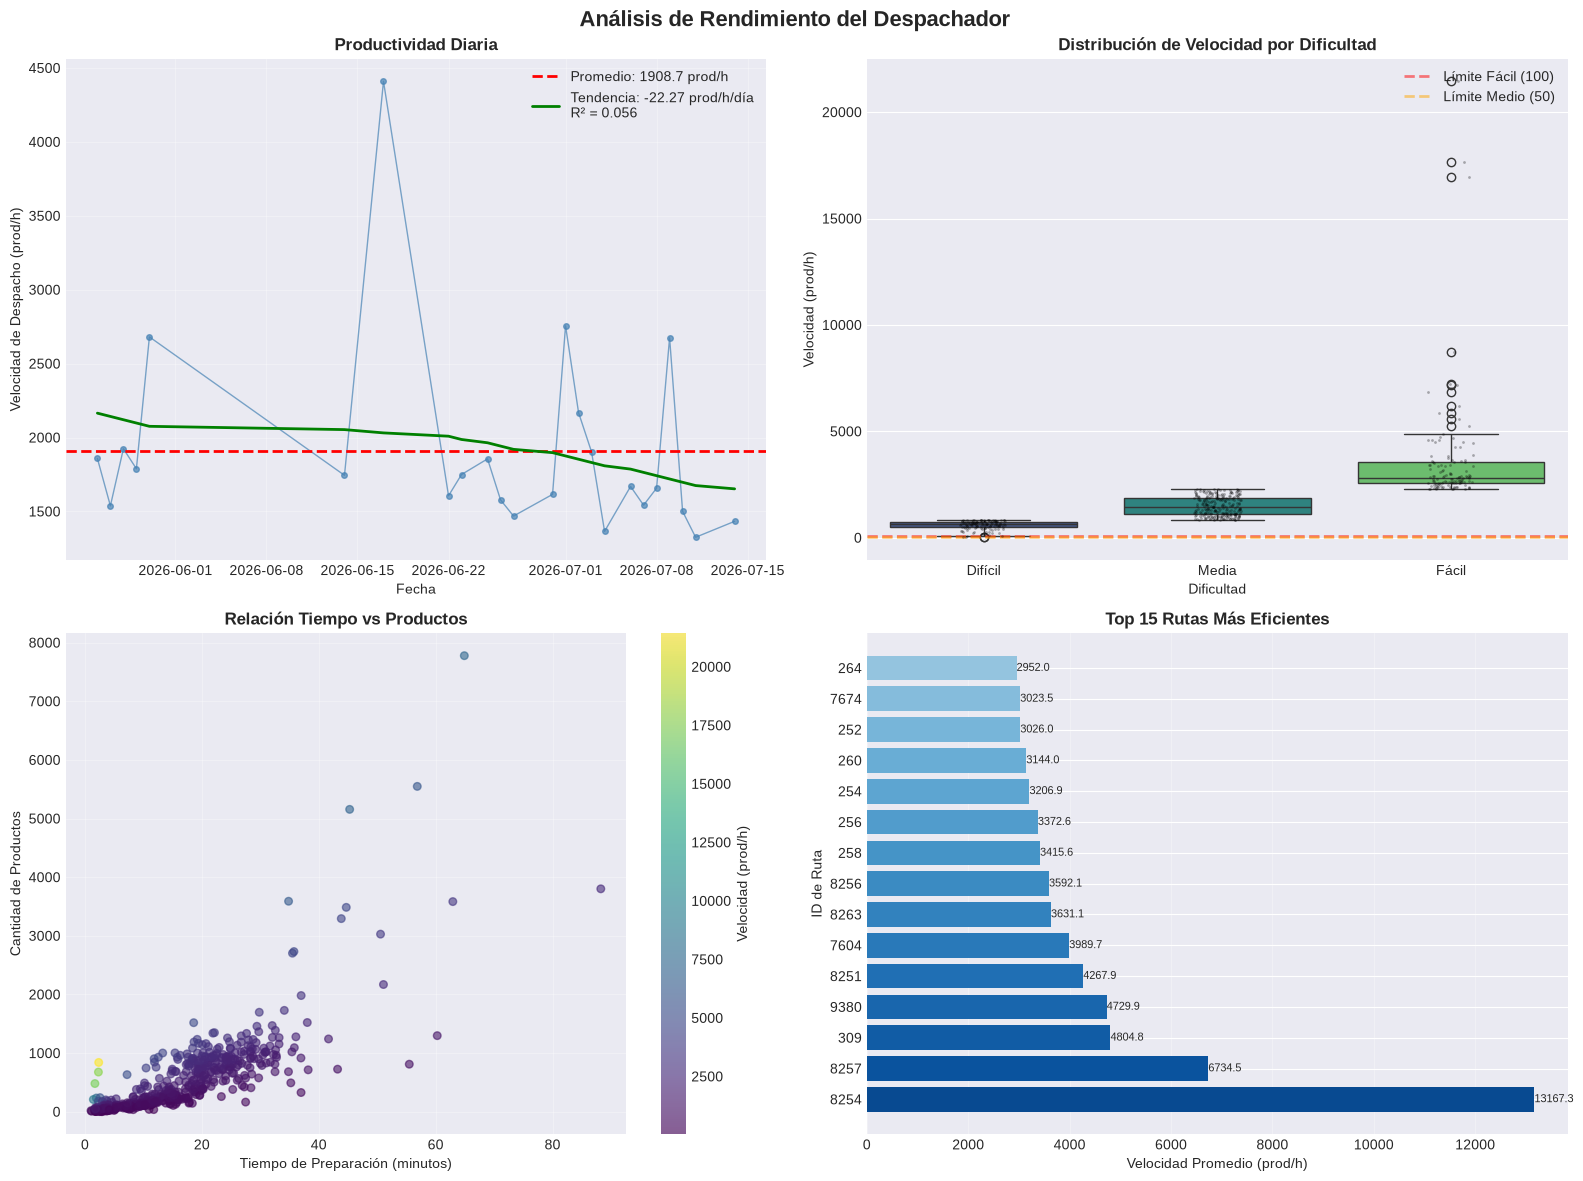



MAPA DE CALOR - CORRELACIÓN ENTRE MÉTRICAS


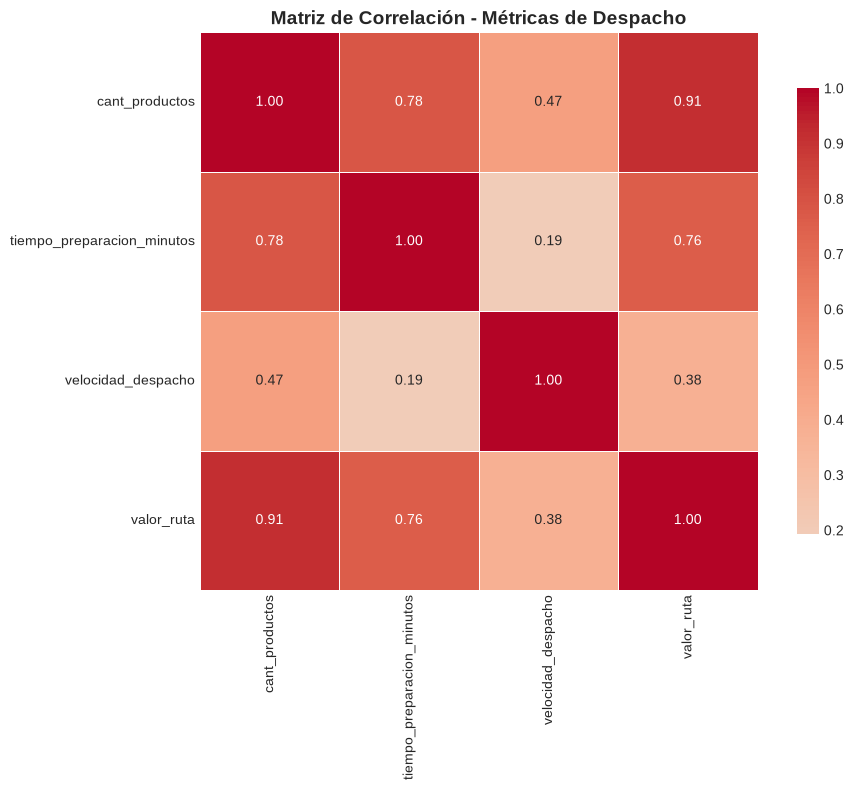


Interpretación de correlaciones:

Correlaciones más fuertes:
  cant_productos ↔ valor_ruta: 0.91
  valor_ruta ↔ cant_productos: 0.91
  tiempo_preparacion_minutos ↔ cant_productos: 0.78

Hallazgos clave:
  • Fuerte correlación positiva entre productos y tiempo (0.78)
    → A más productos, más tiempo de preparación (esperado)
  • Correlación positiva entre velocidad y valor de ruta (0.38)
    → Las rutas más valiosas se despachan más rápido


In [9]:
# Visualizaciones
fig, axes = plt.subplots(2, 2, figsize=(16, 12)) # Crea cuadrícula de 2 filas x 2 columnas (4 gráficos), 16 ancho, 12 alto.

# Título principal de toda la figura
fig.suptitle('Análisis de Rendimiento del Despachador', fontsize=16, fontweight='bold') # Contenedor principal de la figura

# 1. Productividad diaria con tendencia
ax1 = axes[0, 0] # Selecciona el primer gráfico (fila 0, columna 0)
diario_velocidad = df_clean.groupby('fecha')['velocidad_despacho'].mean() # Calcula la velocidad promedio por día

if len(diario_velocidad) > 0: # Verifica que hay datos (len > 0)
    ax1.plot(diario_velocidad.index, diario_velocidad.values, 'o-', alpha=0.7, linewidth=1, markersize=4, color='steelblue') # linea de productividad diaria
    ax1.axhline(diario_velocidad.mean(), color='red', linestyle='--', linewidth=2,
                label=f'Promedio: {diario_velocidad.mean():.1f} prod/h')

    # Línea de tendencia
    if len(diario_velocidad) > 1:
        x = np.arange(len(diario_velocidad))
        y = diario_velocidad.values
        mask = ~np.isnan(y)
        if mask.sum() > 1:
            slope, intercept, r_value, _, _ = linregress(x[mask], y[mask])
            ax1.plot(diario_velocidad.index, intercept + slope * x, 
                    color='green', linestyle='-', linewidth=2, 
                    label=f'Tendencia: {slope:.2f} prod/h/día\nR² = {r_value**2:.3f}')
    
    ax1.set_title('Productividad Diaria', fontsize=12, fontweight='bold') # Título del gráfico
    ax1.set_xlabel('Fecha') # Etiquetas de ejes
    ax1.set_ylabel('Velocidad de Despacho (prod/h)')
    ax1.legend(loc='best') # Muestra la leyenda en la mejor ubicación automáticamente
    ax1.grid(True, alpha=0.3) # Agrega cuadrícula con transparencia 30%

# 2. Boxplot por dificultad
ax2 = axes[0, 1]
sns.boxplot(data=df_clean, x='mi_dificultad', y='velocidad_despacho', ax=ax2, palette='viridis') # Diagrama de caja
sns.stripplot(data=df_clean, x='mi_dificultad', y='velocidad_despacho', 
              alpha=0.3, size=2, ax=ax2, color='black')
ax2.set_title('Distribución de Velocidad por Dificultad', fontsize=12, fontweight='bold')
ax2.set_xlabel('Dificultad')
ax2.set_ylabel('Velocidad (prod/h)')
ax2.axhline(100, color='red', linestyle='--', alpha=0.5, linewidth=2, label='Límite Fácil (100)')
ax2.axhline(50, color='orange', linestyle='--', alpha=0.5, linewidth=2, label='Límite Medio (50)')
ax2.legend(loc='upper right')

# 3. Scatter: Productos vs Tiempo
ax3 = axes[1, 0]
scatter = ax3.scatter(df_clean['tiempo_preparacion_minutos'], 
                     df_clean['cant_productos'],
                     c=df_clean['velocidad_despacho'],
                     cmap='viridis', alpha=0.6, s=30)
ax3.set_xlabel('Tiempo de Preparación (minutos)')
ax3.set_ylabel('Cantidad de Productos')
ax3.set_title('Relación Tiempo vs Productos', fontsize=12, fontweight='bold')
plt.colorbar(scatter, ax=ax3, label='Velocidad (prod/h)')
ax3.grid(True, alpha=0.3)

# 4. Top rutas por rendimiento
ax4 = axes[1, 1]
top_rutas = df_clean.groupby('id_ruta').agg({
    'velocidad_despacho': 'mean',
    'cant_productos': 'sum'
}).sort_values('velocidad_despacho', ascending=False).head(15)

# Colores según eficiencia
colors = plt.cm.Blues(np.linspace(0.4, 0.9, len(top_rutas)))[::-1]
ax4.barh(range(len(top_rutas)), top_rutas['velocidad_despacho'].values, color=colors)
ax4.set_yticks(range(len(top_rutas)))
ax4.set_yticklabels([f"{int(r)}" for r in top_rutas.index])
ax4.set_xlabel('Velocidad Promedio (prod/h)')
ax4.set_ylabel('ID de Ruta')
ax4.set_title('Top 15 Rutas Más Eficientes', fontsize=12, fontweight='bold')
ax4.grid(True, alpha=0.3, axis='x')

# Agregar etiquetas de valores
for i, v in enumerate(top_rutas['velocidad_despacho'].values):
    ax4.text(v + 1, i, f'{v:.1f}', va='center', fontsize=8)

plt.tight_layout()
plt.savefig('../reports/figures/rendimiento_analisis.png', dpi=150, bbox_inches='tight')
plt.show()
plt.close()

# Mapa de calor - Correlación entre métricas

print("\n")
print("MAPA DE CALOR - CORRELACIÓN ENTRE MÉTRICAS")

# Seleccionar columnas numéricas para correlación
columnas_corr = ['cant_productos', 'tiempo_preparacion_minutos', 
                 'velocidad_despacho', 'valor_ruta']

# Calcular matriz de correlación
corr = df_clean[columnas_corr].corr() # Calcula la matriz de correlación de Pearson
"""
Valores entre -1 y 1:
 - 1: Correlación perfecta positiva
 - -1: Correlación perfecta negativa
 - 0: Sin correlación
"""

# Crear figura
fig, ax = plt.subplots(figsize=(10, 8))

# Mapa de calor
sns.heatmap(corr, 
            annot=True,           # Mostrar valores
            cmap='coolwarm',      # Colores fríos/calientes
            center=0,             # Centro en 0
            fmt='.2f',            # Formato de 2 decimales
            square=True,          # Celdas cuadradas
            linewidths=0.5,       # Líneas entre celdas
            cbar_kws={'shrink': 0.8},
            ax=ax)

ax.set_title('Matriz de Correlación - Métricas de Despacho', 
             fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('../reports/figures/correlacion.png', dpi=150, bbox_inches='tight')
plt.show()

# Interpretación de correlaciones
print("\nInterpretación de correlaciones:")

# Correlaciones más fuertes
corr_abs = corr.abs().unstack().sort_values(ascending=False) # Toma el valor absoluto de las correlaciones
corr_abs = corr_abs[corr_abs < 1]  # Elimina diagonal

# Extraer correlaciones específicas
print("\nCorrelaciones más fuertes:")
for i in range(min(3, len(corr_abs))):
    pair = corr_abs.index[i]
    val = corr_abs.values[i]
    print(f"  {pair[0]} ↔ {pair[1]}: {val:.2f}")

# Análisis de la correlación más importante
corr_productos_tiempo = corr.loc['cant_productos', 'tiempo_preparacion_minutos']
corr_velocidad_valor = corr.loc['velocidad_despacho', 'valor_ruta']

print(f"\nHallazgos clave:")
if corr_productos_tiempo > 0.7:
    print(f"  • Fuerte correlación positiva entre productos y tiempo ({corr_productos_tiempo:.2f})")
    print("    → A más productos, más tiempo de preparación (esperado)")
elif corr_productos_tiempo > 0.3:
    print(f"  • Correlación moderada entre productos y tiempo ({corr_productos_tiempo:.2f})")
else:
    print(f"  • Baja correlación entre productos y tiempo ({corr_productos_tiempo:.2f})")
    print("    → El tiempo no depende solo de la cantidad de productos")

if corr_velocidad_valor > 0.3:
    print(f"  • Correlación positiva entre velocidad y valor de ruta ({corr_velocidad_valor:.2f})")
    print("    → Las rutas más valiosas se despachan más rápido")
elif corr_velocidad_valor < -0.3:
    print(f"  • Correlación negativa entre velocidad y valor de ruta ({corr_velocidad_valor:.2f})")
    print("    → Las rutas más valiosas toman más tiempo")
else:
    print(f"  • Baja correlación entre velocidad y valor de ruta ({corr_velocidad_valor:.2f})")

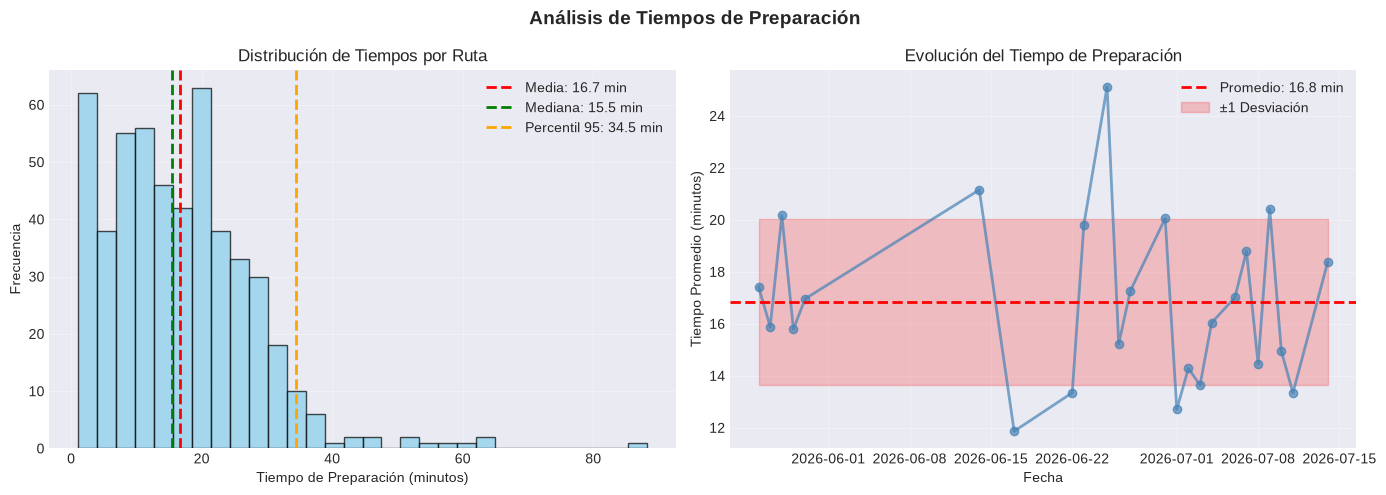

In [10]:
# Distribución de tiempos de preparación
# Configuración de la figura
fig, axes = plt.subplots(1, 2, figsize=(14, 5)) # Cuadrícula de 1 fila x 2 columnas
fig.suptitle('Análisis de Tiempos de Preparación', fontsize=14, fontweight='bold') # Título principal de toda la figura

# Histograma para mostrar distribución de frecuencias
ax1 = axes[0]
ax1.hist(df_clean['tiempo_preparacion_minutos'], bins=30, color='skyblue', edgecolor='black', alpha=0.7)
ax1.axvline(df_clean['tiempo_preparacion_minutos'].mean(), color='red', linestyle='--', linewidth=2,
            label=f'Media: {df_clean["tiempo_preparacion_minutos"].mean():.1f} min')
ax1.axvline(df_clean['tiempo_preparacion_minutos'].median(), color='green', linestyle='--', linewidth=2,
            label=f'Mediana: {df_clean["tiempo_preparacion_minutos"].median():.1f} min')

# Agregar percentil 95
p95 = df_clean['tiempo_preparacion_minutos'].quantile(0.95)
ax1.axvline(p95, color='orange', linestyle='--', linewidth=2,
            label=f'Percentil 95: {p95:.1f} min')
ax1.set_xlabel('Tiempo de Preparación (minutos)')
ax1.set_ylabel('Frecuencia')
ax1.set_title('Distribución de Tiempos por Ruta')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2 = axes[1]

# Evolución del tiempo promedio por día
tiempo_diario = df_clean.groupby('fecha')['tiempo_preparacion_minutos'].mean() # Calcula el tiempo promedio de preparación por día
ax2.plot(tiempo_diario.index, tiempo_diario.values, 'o-', alpha=0.7, color='steelblue', linewidth=2)
ax2.axhline(tiempo_diario.mean(), color='red', linestyle='--', linewidth=2,
            label=f'Promedio: {tiempo_diario.mean():.1f} min') # Calcula el promedio de todos los día
ax2.fill_between(tiempo_diario.index, 
                 tiempo_diario.mean() - tiempo_diario.std(),
                 tiempo_diario.mean() + tiempo_diario.std(),
                 alpha=0.2, color='red', label='±1 Desviación') # Rellena el ártea entre dos líneas
# Configuración del gráfico
ax2.set_xlabel('Fecha')
ax2.set_ylabel('Tiempo Promedio (minutos)')
ax2.set_title('Evolución del Tiempo de Preparación')
ax2.legend()
ax2.grid(True, alpha=0.3)

# Guardar y mostrar
plt.tight_layout()
plt.savefig('../reports/figures/tiempos_preparacion.png', dpi=150, bbox_inches='tight')
plt.show()
plt.close()

## 7. Persistencia en SQLite <a id='persistenciaensql'></a>
[Índice](#indice)

Se guardan los datos procesados en una base de datos SQL para consultas rápidas y análisis posteriores.
- **Base de datos:** `rendimiento.db`
- **Tabla:** `despachos`
- **Columnas:** fehca, id_ruta, tiempo_preparacion_minutos, cant_productos, valor_ruta, velocidad_despacho, mi_dificultad

In [11]:
# Crear base de datos y guardar datos

print("GUARDANDO DATOS EN SQLITE")

if len(df_clean) == 0: # Validamos que tiene datos
    print("No hay datos para guardar")
else:
    # Crear conexión
    conn = sqlite3.connect('../data/processed/rendimiento.db')
    
    # Seleccionar columnas para guardar
    columnas_guardar = ['fecha', 'id_ruta', 'tiempo_preparacion_minutos', 
                       'cant_productos', 'valor_ruta', 'velocidad_despacho', 'mi_dificultad', 'dificultad_cuartiles']
    df_db = df_clean[columnas_guardar].copy()
    
    # Renombrar columnas para SQL
    df_db.columns = ['fecha', 'id_ruta', 'tiempo_preparacion_minutos', 
                    'cant_productos', 'valor_ruta', 'velocidad_despacho', 'mi_dificultad', 'dificultad_cuartiles']
    
    # Guardar en SQL
    df_db.to_sql('despachos', conn, if_exists='replace', index=False)
    print(f"Datos guardados en SQLite: {len(df_db):,} registros")
    
    # Consultas SQL
    def ejecutar_consulta(conn, query, titulo):
        """Ejecuta una consulta SQL y muestra resultados"""
        print("\n")
        print(f"{titulo}")

        try:
            result = pd.read_sql_query(query, conn)
            display(result)
            return result
        except Exception as e:
            print(f"Error en consulta: {e}")
            return None
    
    # Consulta 1: Top 10 rutas más eficientes
    query1 = """
    SELECT 
        id_ruta,
        ROUND(AVG(velocidad_despacho), 2) as velocidad_promedio,
        SUM(cant_productos) as total_productos,
        COUNT(*) as num_rutas,
        ROUND(AVG(tiempo_preparacion_minutos), 1) as tiempo_promedio
    FROM despachos
    GROUP BY id_ruta
    ORDER BY velocidad_promedio DESC
    LIMIT 10
    """
    top_rutas_sql = ejecutar_consulta(conn, query1, "TOP 10 RUTAS MÁS EFICIENTES")
    
    # Consulta 2: Días récord de producto
    query2 = """
    SELECT 
        fecha,
        SUM(cant_productos) as productos_dia,
        ROUND(AVG(velocidad_despacho), 2) as velocidad_promedio,
        COUNT(*) as rutas_dia
    FROM despachos
    GROUP BY fecha
    ORDER BY productos_dia DESC
    LIMIT 10
    """
    dias_record = ejecutar_consulta(conn, query2, "DÍAS RÉCORD DE PRODUCTO")
    
    # Consulta 3: Promedio de velocidad por rango de valor de ruta
    query3 = """
    SELECT 
        CASE 
            WHEN valor_ruta < 500000 THEN 'Bajo (<500k)'
            WHEN valor_ruta < 2000000 THEN 'Medio (500k-2M)'
            WHEN valor_ruta < 5000000 THEN 'Alto (2M-5M)'
            ELSE 'Muy Alto (>5M)'
        END as rango_valor,
        ROUND(AVG(velocidad_despacho), 2) as velocidad_promedio,
        ROUND(AVG(cant_productos), 1) as productos_promedio,
        COUNT(*) as num_rutas,
        ROUND(AVG(tiempo_preparacion_minutos), 1) as tiempo_promedio
    FROM despachos
    WHERE valor_ruta IS NOT NULL
    GROUP BY rango_valor
    ORDER BY velocidad_promedio DESC
    """
    rangos_valor = ejecutar_consulta(conn, query3, "VELOCIDAD POR RANGO DE VALOR")
    
    # Cerrar conexión
    conn.close()
    print("\nBase de datos guardada en '../data/processed/rendimiento.db'")


GUARDANDO DATOS EN SQLITE
Datos guardados en SQLite: 510 registros


TOP 10 RUTAS MÁS EFICIENTES


,id_ruta,velocidad_promedio,total_productos,num_rutas,tiempo_promedio
0,8254,13167.29,1768,4,2.0
1,8257,6734.50,16522,3,48.3
2,309,4804.81,6188,7,18.2
3,9380,4729.93,180,1,2.3
4,8251,4267.89,8279,3,35.5
5,7604,3989.68,10443,4,39.7
6,8263,3631.05,7286,2,66.5
7,8256,3592.15,7056,3,36.9
8,258,3415.62,3766,4,17.2
9,256,3372.59,6053,6,18.3




DÍAS RÉCORD DE PRODUCTO


,fecha,productos_dia,velocidad_promedio,rutas_dia
0,2026-07-06 00:00:00,16703,1669.10,25
1,2026-05-30 00:00:00,16414,2680.69,21
2,2026-07-11 00:00:00,15667,1325.17,36
3,2026-05-26 00:00:00,15548,1858.46,18
4,2026-06-22 00:00:00,15073,1605.78,31
5,2026-07-09 00:00:00,14755,2674.51,22
6,2026-06-30 00:00:00,14373,1615.30,23
7,2026-07-14 00:00:00,14096,1433.01,25
8,2026-07-08 00:00:00,13150,1657.45,28
9,2026-06-25 00:00:00,12797,1855.51,16




VELOCIDAD POR RANGO DE VALOR


,rango_valor,velocidad_promedio,productos_promedio,num_rutas,tiempo_promedio
0,Muy Alto (>5M),3388.58,2270.0,29,37.2
1,Alto (2M-5M),2226.89,824.0,181,23.3
2,Medio (500k-2M),1624.01,310.2,206,13.2
3,Bajo (<500k),803.68,58.4,94,5.1



Base de datos guardada en '../data/processed/rendimiento.db'


In [12]:
# Guardar CSV limpio
if len(df_clean) > 0:
    df_clean.to_csv('../data/processed/despachos_clean.csv', index=False)
    print(f"Datos limpios guardados en '../data/processed/despachos_clean.csv'")
    print(f"   {len(df_clean):,} registros guardados")
else:
    print("No hay datos para guardar")

Datos limpios guardados en '../data/processed/despachos_clean.csv'
   510 registros guardados


## 8. Conclusiones y Recomendaciones <a id='conclusiones'></a>
[Índice](#indice)

### Hallazgos Clave


In [13]:
# Conclusiones y Recomendaciones

print("Conclusiones y Recomendaciones")

# Métricas principales
velocidad_mean = df_clean['velocidad_despacho'].mean()
velocidad_median = df_clean['velocidad_despacho'].median()
velocidad_max = df_clean['velocidad_despacho'].max()
dias_trabajados = df_clean['fecha'].nunique()
total_rutas = len(df_clean)

# Umbrales reales por Cuartiles (Consistente con los gráficos y DB)
p25 = df_clean['velocidad_despacho'].quantile(0.25)
p75 = df_clean['velocidad_despacho'].quantile(0.75)

# Forzar el cálculo de correlaciones del mapa de calor
columnas_corr = ['cant_productos', 'tiempo_preparacion_minutos', 'velocidad_despacho', 'valor_ruta']
corr = df_clean[columnas_corr].corr()
corr_productos_tiempo = corr.loc['cant_productos', 'tiempo_preparacion_minutos']
corr_velocidad_valor = corr.loc['velocidad_despacho', 'valor_ruta']

# Interpretación de correlaciones
prod_tiempo_texto = "Fuerte" if corr_productos_tiempo > 0.7 else ("Moderada" if corr_productos_tiempo > 0.3 else "Baja")
vel_valor_texto = "Positiva Moderada" if corr_velocidad_valor > 0.3 else ("Negativa" if corr_velocidad_valor < -0.3 else "Baja")

# RESUMEN DE MÉTRICAS LOGÍSTICAS
print(f"""
┌─────────────────────────────────────┬────────────────────────┐
│ Métrica Principal                   │ Valor                  │
├─────────────────────────────────────┼────────────────────────┤
│ Total de rutas analizadas           │ {total_rutas:>22,} │
│ Velocidad promedio histórica        │ {velocidad_mean:>14.1f} prod/h │
│ Velocidad mediana (50% de rutas)    │ {velocidad_median:>14.1f} prod/h │
│ Velocidad máxima registrada         │ {velocidad_max:>14.1f} prod/h │
│ Días de operación evaluados         │ {dias_trabajados:>22} │
└─────────────────────────────────────┴────────────────────────┘
""")

# DISTRIBUCIÓN DE DIFICULTAD (Mapeado con Machine Learning)
print(f"""
SEGMENTACIÓN OPERATIVA POR CUARTILES
┌───────────────────────────┬─────────────────────┬─────────────┐
│ Categoría de Ruta         │ Rango de Velocidad  │ % de Rutas  │
├───────────────────────────┼─────────────────────┼─────────────┤
│ Fácil (Alta velocidad)    │ > {p75:>13.0f}     │         25% │
│ Media (Velocidad normal)  │ {p25:>5.0f} - {p75:<5.0f}       │         50% │
│ Difícil (Baja velocidad)  │ < {p25:>13.0f}     │         25% │
└───────────────────────────┴─────────────────────┴─────────────┘
""")

print(f"""
DIAGNÓSTICO DE CORRELACIONES (HALLAZGOS CLAVE)
--------------------------------------------------------------------------------
• Volumen vs Tiempo: {corr_productos_tiempo:.2f} ({prod_tiempo_texto})
  A mayor cantidad de productos, el tiempo de preparación escala de forma predecible.
• Eficiencia vs Valor Comercial: {corr_velocidad_valor:.2f} ({vel_valor_texto})
  Existe una tendencia a despachar más rápido las rutas de alto valor monetario, 
  lo cual está fuertemente impulsado por el gran volumen concentrado en ellas.
""")

print("""
RECOMENDACIONES ESTRATÉGICAS PARA EL NEGOCIO
--------------------------------------------------------------------------------
1. ATACAR EL "HORMIGUEO" (Rutas Difíciles):
   Las rutas en el bottom 25% representan un cuello de botella de eficiencia. Se recomienda
   revisar el método de picking manual para pedidos pequeños, buscando consolidar viajes.

2. REPLICAR EL MODELO CROSS-DOCKING:
   Estudiar a fondo las dinámicas de las rutas que superan el percentil 75 (ej. la ruta 8254) 
   para estandarizar sus procesos de carga directa en los camiones.

3. TRANSICIÓN A LA FASE 2 (PREDICCIÓN CON IA):
   Dado que las correlaciones demuestran patrones lineales estables entre Productos, Valor 
   y Tiempo, el dataset está óptimo para entrenar un modelo predictivo supervisado.
""")


Conclusiones y Recomendaciones

┌─────────────────────────────────────┬────────────────────────┐
│ Métrica Principal                   │ Valor                  │
├─────────────────────────────────────┼────────────────────────┤
│ Total de rutas analizadas           │                    510 │
│ Velocidad promedio histórica        │         1787.1 prod/h │
│ Velocidad mediana (50% de rutas)    │         1454.3 prod/h │
│ Velocidad máxima registrada         │        21446.8 prod/h │
│ Días de operación evaluados         │                     24 │
└─────────────────────────────────────┴────────────────────────┘


SEGMENTACIÓN OPERATIVA POR CUARTILES
┌───────────────────────────┬─────────────────────┬─────────────┐
│ Categoría de Ruta         │ Rango de Velocidad  │ % de Rutas  │
├───────────────────────────┼─────────────────────┼─────────────┤
│ Fácil (Alta velocidad)    │ >          2277     │         25% │
│ Media (Velocidad normal)  │   839 - 2277        │         50% │
│ Difícil (Baja v

In [14]:

# Resumen Ejecutivo
print("RESUMEN EJECUTIVO")

print(f"Reporte generado: {datetime.now().strftime('%Y-%m-%d %H:%M')}")

if len(df_clean) > 0:
    # Calcular métricas principales
    velocidad_mean = df_clean['velocidad_despacho'].mean()
    velocidad_median = df_clean['velocidad_despacho'].median()
    velocidad_std = df_clean['velocidad_despacho'].std()
    productos_mean = df_clean['cant_productos'].mean()
    tiempo_mean = df_clean['tiempo_preparacion_minutos'].mean()
    
    # Distribución de dificultad
    facil = len(df_clean[df_clean['mi_dificultad'] == 'Fácil'])
    media = len(df_clean[df_clean['mi_dificultad'] == 'Media'])
    dificil = len(df_clean[df_clean['mi_dificultad'] == 'Difícil'])
    facil_pct = facil / len(df_clean) * 100
    media_pct = media / len(df_clean) * 100
    dificil_pct = dificil / len(df_clean) * 100
    
    # Top rutas eficientes
    top_rutas = df_clean.groupby('id_ruta')['velocidad_despacho'].mean().sort_values(ascending=False).head(3)
    top_rutas_str = ', '.join([str(int(r)) for r in top_rutas.index])
    
    # Análisis de tendencia
    if 'slope' in locals() and 'p_value' in locals():
        if p_value < 0.05 and slope > 0:
            tendencia_texto = "Mejora significativa"
        elif p_value < 0.05 and slope < 0:
            tendencia_texto = "Disminución significativa"
        else:
            tendencia_texto = "Estable o sin cambio significativo"
    else:
        tendencia_texto = "Sin datos suficientes"
    
    print(f"""
ESTADÍSTICAS GENERALES:
- Total de rutas analizadas: {len(df_clean):,}
- Período analizado: {df_clean['fecha'].min().strftime('%Y-%m-%d')} a {df_clean['fecha'].max().strftime('%Y-%m-%d')}
- Días trabajados: {df_clean['fecha'].nunique()}

MÉTRICAS DE RENDIMIENTO:
- Velocidad promedio: {velocidad_mean:.1f} prod/h
- Velocidad mediana: {velocidad_median:.1f} prod/h
- Desviación estándar: {velocidad_std:.1f} prod/h
- Productos por ruta promedio: {productos_mean:.1f}
- Tiempo de preparación promedio: {tiempo_mean:.1f} min

CLASIFICACIÓN DE RUTAS:
- Fáciles (>100 prod/h): {facil:,} ({facil_pct:.1f}%)
- Medias (50-100 prod/h): {media:,} ({media_pct:.1f}%)
- Difíciles (<50 prod/h): {dificil:,} ({dificil_pct:.1f}%)

RECOMENDACIONES:
1. Las rutas difíciles representan el {dificil_pct:.1f}% de los despachos
2. {tendencia_texto}
3. Enfoque en replicar prácticas de las rutas {top_rutas_str}
4. Revisar las rutas con menor velocidad para identificar oportunidades de mejora
5. Mantener un registro de condiciones que afectan mi rendimiento
""")
else:
    print("No hay datos suficientes para generar el resumen")

print("\n")
print("FASE 1 COMPLETADA")

RESUMEN EJECUTIVO
Reporte generado: 2026-07-15 12:59

ESTADÍSTICAS GENERALES:
- Total de rutas analizadas: 510
- Período analizado: 2026-05-26 a 2026-07-14
- Días trabajados: 24

MÉTRICAS DE RENDIMIENTO:
- Velocidad promedio: 1787.1 prod/h
- Velocidad mediana: 1454.3 prod/h
- Desviación estándar: 1735.3 prod/h
- Productos por ruta promedio: 557.6
- Tiempo de preparación promedio: 16.7 min

CLASIFICACIÓN DE RUTAS:
- Fáciles (>100 prod/h): 128 (25.1%)
- Medias (50-100 prod/h): 254 (49.8%)
- Difíciles (<50 prod/h): 128 (25.1%)

RECOMENDACIONES:
1. Las rutas difíciles representan el 25.1% de los despachos
2. Estable o sin cambio significativo
3. Enfoque en replicar prácticas de las rutas 8254, 8257, 309
4. Revisar las rutas con menor velocidad para identificar oportunidades de mejora
5. Mantener un registro de condiciones que afectan mi rendimiento



FASE 1 COMPLETADA
